In [1]:
# Load the necessary libraries
import os
import glob
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from timm import create_model
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Define the CombinedDataset class
class CombinedDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            image = Image.open(self.image_paths[idx]).convert('RGB')
            label = self.labels[idx]
            if self.transform:
                image = self.transform(image)
            return image, torch.tensor(label, dtype=torch.long)
        except Exception as e:
            print(f"Error loading image {self.image_paths[idx]}: {str(e)}")
            return None

In [3]:
# Define the collate function
def collate_fn(batch):
    batch = list(filter(lambda x: x is not None, batch))
    if len(batch) == 0:
        return None
    images = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    return images, labels

In [4]:
# Load the test dataset
def load_test_data(base_dir, transform):
    ied_dir = os.path.join(base_dir, 'ied_data')
    trashnet_dir = os.path.join(base_dir, 'trashnet_data')

    ied_test_paths = glob.glob(os.path.join(ied_dir, 'test', '*.*'))
    ied_test_labels = [0] * len(ied_test_paths)

    trashnet_test_paths = []
    trashnet_test_labels = []
    label_map = {'glass': 1, 'paper': 2, 'cardboard': 3, 'plastic': 4, 'metal': 5, 'trash': 6}
    for category, label in label_map.items():
        category_path = os.path.join(trashnet_dir, category)
        if os.path.isdir(category_path):
            category_images = glob.glob(os.path.join(category_path, '*.*'))
            trashnet_test_paths.extend(category_images)
            trashnet_test_labels.extend([label] * len(category_images))

    test_paths = ied_test_paths + trashnet_test_paths
    test_labels = ied_test_labels + trashnet_test_labels

    test_dataset = CombinedDataset(test_paths, test_labels, transform)
    return test_dataset

In [5]:
# Hyperparameters
batch_size = 16
num_classes = 7
image_size = 224
num_workers = 0

In [6]:
# Set up data transforms
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
# Load the test dataset
base_dir = r'C:\Users\nisin\OneDrive\Documents\MIT\MDA522 Artificial Intelligence\Assignments\Assignment 2'
test_dataset = load_test_data(base_dir, transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collate_fn)

In [8]:
# Load the model
model = create_model('swin_base_patch4_window7_224', pretrained=False, num_classes=num_classes)
model.load_state_dict(torch.load('best_waste_detection_model.pth'))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

C:\Users\nisin\AppData\Local\Temp\ipykernel_9548\514896474.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_waste_detection_model.p

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=128, out_features=384, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=128, out_features=128, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=128, out_features=512, bias=True)
            (act): GELU(approximate='none')
            (

In [9]:
# Evaluation
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        if batch is None:
            continue
        images, labels = batch
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [10]:
# Calculate overall metrics
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
conf_matrix = confusion_matrix(all_labels, all_preds)

print("Overall Metrics:")
print(f'Test Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Overall Metrics:
Test Accuracy: 0.9855
Precision: 0.9856
Recall: 0.9855
F1 Score: 0.9855


In [11]:
# Calculate per-category metrics
class_names = ['IED', 'Glass', 'Paper', 'Cardboard', 'Plastic', 'Metal', 'Trash']
per_class_precision, per_class_recall, per_class_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None)

print("\nPer-Category Metrics:")
for i, class_name in enumerate(class_names):
    print(f"\n{class_name}:")
    print(f'Precision: {per_class_precision[i]:.4f}')
    print(f'Recall: {per_class_recall[i]:.4f}')
    print(f'F1 Score: {per_class_f1[i]:.4f}')


Per-Category Metrics:

IED:
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

Glass:
Precision: 0.9784
Recall: 0.9940
F1 Score: 0.9861

Paper:
Precision: 0.9833
Recall: 0.9933
F1 Score: 0.9883

Cardboard:
Precision: 0.9950
Recall: 0.9926
F1 Score: 0.9938

Plastic:
Precision: 0.9936
Recall: 0.9689
F1 Score: 0.9811

Metal:
Precision: 0.9878
Recall: 0.9878
F1 Score: 0.9878

Trash:
Precision: 0.9559
Recall: 0.9489
F1 Score: 0.9524


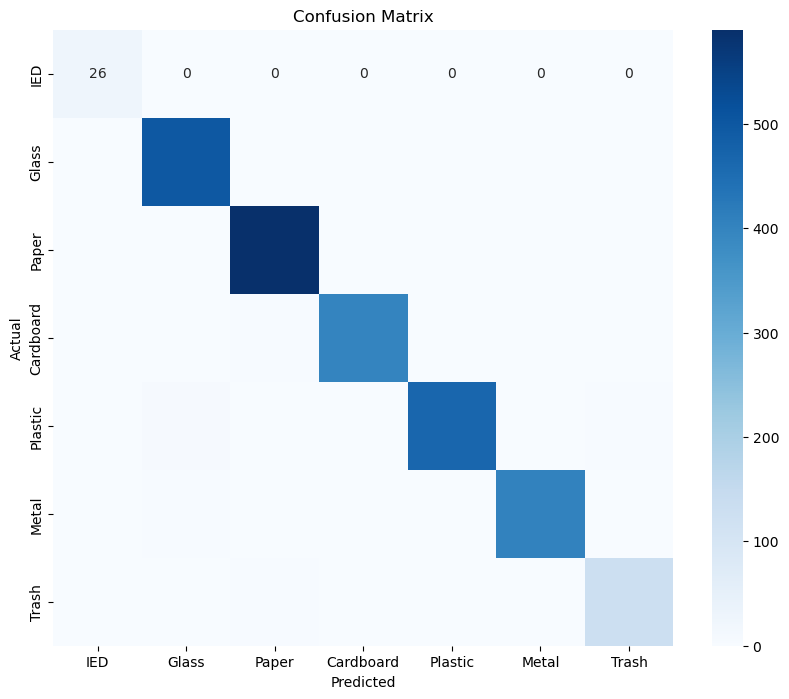

In [12]:
# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()